In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

RecursionError: maximum recursion depth exceeded

In [30]:
df= pd.read_csv("analise_robusta.csv")

In [31]:
df

,Estado,UF,IDHM Educação 2012,IDHM Educação 2013,IDHM Educação 2014,IDHM Educação 2015,IDHM Educação 2016,IDHM Educação 2017,IDHM Educação 2018,IDHM Educação 2019,...,Índice de Atkinson - Renda 2012,Índice de Atkinson - Renda 2013,Índice de Atkinson - Renda 2014,Índice de Atkinson - Renda 2015,Índice de Atkinson - Renda 2016,Índice de Atkinson - Renda 2017,Índice de Atkinson - Renda 2018,Índice de Atkinson - Renda 2019,Índice de Atkinson - Renda 2020,Índice de Atkinson - Renda 2021
0,Acre,AC,0.649,0.658,0.679,0.679,0.704,0.671,0.706,0.728,...,0.422,0.402,0.393,0.404,0.404,0.422,0.440,0.454,0.378,0.432
1,Alagoas,AL,0.587,0.573,0.599,0.605,0.635,0.634,0.651,0.643,...,0.352,0.371,0.383,0.381,0.393,0.395,0.437,0.405,0.366,0.397
2,Amapá,AP,0.659,0.714,0.688,0.690,0.709,0.700,0.742,0.728,...,0.361,0.348,0.349,0.398,0.419,0.421,0.428,0.376,0.365,0.401
3,Amazonas,AM,0.632,0.659,0.667,0.686,0.705,0.732,0.717,0.735,...,0.417,0.389,0.393,0.396,0.416,0.438,0.405,0.424,0.392,0.410
4,Bahia,BA,0.593,0.594,0.619,0.640,0.656,0.655,0.660,0.672,...,0.405,0.385,0.366,0.378,0.383,0.422,0.417,0.418,0.369,0.411
5,Ceará,CE,0.667,0.667,0.679,0.689,0.708,0.715,0.740,0.740,...,0.406,0.387,0.366,0.383,0.389,0.396,0.400,0.405,0.388,0.418
6,Distrito Federal,DF,0.768,0.794,0.791,0.789,0.822,0.797,0.808,0.842,...,0.417,0.410,0.396,0.393,0.400,0.424,0.417,0.376,0.387,0.421
7,Espírito Santo,ES,0.692,0.701,0.709,0.726,0.732,0.731,0.743,0.741,...,0.327,0.335,0.335,0.337,0.346,0.352,0.344,0.355,0.335,0.371
8,Goiás,GO,0.698,0.710,0.723,0.722,0.754,0.743,0.757,0.770,...,0.293,0.280,0.293,0.278,0.302,0.312,0.320,0.308,0.289,0.306
9,Maranhão,MA,0.611,0.639,0.639,0.649,0.673,0.684,0.685,0.704,...,0.368,0.348,0.331,0.359,0.375,0.383,0.414,0.413,0.347,0.413


## 1- Valor Medio BolsaFamilia Ajustada pela quanrtidade de abandono EF

In [32]:
# Supondo que o DataFrame original se chame 'df'
# Criar DataFrame para Abandono no Ensino Fundamental
abandono_ef = df.melt(
    id_vars=["UF"],  # Coluna fixa
    value_vars=[col for col in df.columns if "Abandono_EF" in col],  # Selecionar colunas de abandono
    var_name="Ano",  # Nome da nova coluna que armazenará os anos
    value_name="Abandono_EF"  # Nome da coluna com os valores de abandono
)
# Extrair o ano do nome da coluna (ex.: "Abandono_EF2007" → 2007)
abandono_ef["Ano"] = abandono_ef["Ano"].str.extract(r'(\d{4})').astype(int)

# Criar DataFrame para Valor Médio do Bolsa Família
valor_bf = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "valor_medio_bf_ajustado_" in col],
    var_name="Ano",
    value_name="Valor_medio_BF"
)
valor_bf["Ano"] = valor_bf["Ano"].str.extract(r'(\d{4})').astype(int)

# Juntar os DataFrames por Estado e Ano
df_final = pd.merge(abandono_ef, valor_bf, on=["UF", "Ano"])

# Verificar os primeiros registros
print(df_final.head())

   UF   Ano  Abandono_EF  Valor_medio_BF
0  AC  2007         4470          184.37
1  AL  2007        48121          175.03
2  AP  2007         6930          189.19
3  AM  2007        51244          189.42
4  BA  2007       185146          178.15


In [33]:
IDHM_EDUCACAO = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "IDHM Educação" in col],
    var_name="Ano",
    value_name="IDHM Educação"
)
IDHM_EDUCACAO ["Ano"] = IDHM_EDUCACAO["Ano"].str.extract(r'(\d{4})').astype(int)


# Juntar os DataFrames por Estado e Ano
df_final = pd.merge(df_final, IDHM_EDUCACAO, on=["UF", "Ano"])

# Verificar os primeiros registros
print(df_final.head())




   UF   Ano  Abandono_EF  Valor_medio_BF  IDHM Educação
0  AC  2012         5270          361.93          0.649
1  AL  2012        44245          294.55          0.587
2  AP  2012         5039          343.57          0.659
3  AM  2012        42742          338.33          0.632
4  BA  2012       127753          285.55          0.593


In [34]:
IDHM_RENDA = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "IDHM Renda" in col],
    var_name="Ano",
    value_name="IDHM Renda"
)
IDHM_RENDA["Ano"] = IDHM_RENDA["Ano"].str.extract(r'(\d{4})').astype(int)


# Juntar os DataFrames por Estado e Ano
df_final = pd.merge(df_final, IDHM_RENDA, on=["UF", "Ano"])

# Verificar os primeiros registros
print(df_final.head())



   UF   Ano  Abandono_EF  Valor_medio_BF  IDHM Educação  IDHM Renda
0  AC  2012         5270          361.93          0.649       0.670
1  AL  2012        44245          294.55          0.587       0.627
2  AP  2012         5039          343.57          0.659       0.673
3  AM  2012        42742          338.33          0.632       0.683
4  BA  2012       127753          285.55          0.593       0.666


In [35]:
INDICE_ATKINSON= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "Índice de Atkinson - Renda" in col],
    var_name="Ano",
    value_name="Índice de Atkinson"
)
INDICE_ATKINSON["Ano"] = INDICE_ATKINSON["Ano"].str.extract(r'(\d{4})').astype(int)


# Juntar os DataFrames por Estado e Ano
df_final = pd.merge(df_final, INDICE_ATKINSON, on=["UF", "Ano"])

# Verificar os primeiros registros
print(df_final.head())

   UF   Ano  Abandono_EF  Valor_medio_BF  IDHM Educação  IDHM Renda  \
0  AC  2012         5270          361.93          0.649       0.670   
1  AL  2012        44245          294.55          0.587       0.627   
2  AP  2012         5039          343.57          0.659       0.673   
3  AM  2012        42742          338.33          0.632       0.683   
4  BA  2012       127753          285.55          0.593       0.666   

   Índice de Atkinson  
0               0.422  
1               0.352  
2               0.361  
3               0.417  
4               0.405  


In [36]:

QTD_FAMILIAS= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "qtd_familias_beneficiarias_bolsa_familia_ajustado_" in col],
    var_name="Ano",
    value_name="QTD_FAMILIAS_BF"
)
QTD_FAMILIAS["Ano"] = QTD_FAMILIAS["Ano"].str.extract(r'(\d{4})').astype(int)


# Juntar os DataFrames por Estado e Ano
df_final = pd.merge(df_final,QTD_FAMILIAS, on=["UF", "Ano"])

# Verificar os primeiros registros
print(df_final.head())


   UF   Ano  Abandono_EF  Valor_medio_BF  IDHM Educação  IDHM Renda  \
0  AC  2012         5270          361.93          0.649       0.670   
1  AL  2012        44245          294.55          0.587       0.627   
2  AP  2012         5039          343.57          0.659       0.673   
3  AM  2012        42742          338.33          0.632       0.683   
4  BA  2012       127753          285.55          0.593       0.666   

   Índice de Atkinson  QTD_FAMILIAS_BF  
0               0.422          67021.0  
1               0.352         429494.0  
2               0.361          52285.0  
3               0.417         323646.0  
4               0.405        1777116.0  


In [37]:
df_final

,UF,Ano,Abandono_EF,Valor_medio_BF,IDHM Educação,IDHM Renda,Índice de Atkinson,QTD_FAMILIAS_BF
0,AC,2012,5270,361.93,0.649,0.670,0.422,67021.0
1,AL,2012,44245,294.55,0.587,0.627,0.352,429494.0
2,AP,2012,5039,343.57,0.659,0.673,0.361,52285.0
3,AM,2012,42742,338.33,0.632,0.683,0.417,323646.0
4,BA,2012,127753,285.55,0.593,0.666,0.405,1777116.0
...,...,...,...,...,...,...,...,...
265,RR,2021,1547,152.57,0.673,0.680,0.447,43082.0
266,SC,2021,3601,125.56,0.790,0.759,0.256,115584.0
267,SP,2021,32381,111.70,0.839,0.771,0.352,1394844.0
268,SE,2021,4489,96.25,0.684,0.662,0.426,239099.0


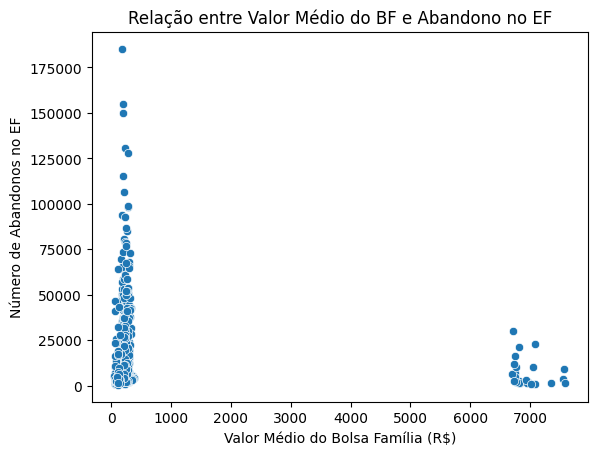

In [34]:
sns.scatterplot(data=df_final, x="Valor_medio_BF", y="Abandono_EF")
plt.title("Relação entre Valor Médio do BF e Abandono no EF")
plt.xlabel("Valor Médio do Bolsa Família (R$)")
plt.ylabel("Número de Abandonos no EF")
plt.show()

In [35]:
correlacao = df_final[["Abandono_EF", "Valor_medio_BF"]].corr()
print(correlacao)

                Abandono_EF  Valor_medio_BF
Abandono_EF         1.00000        -0.14441
Valor_medio_BF     -0.14441         1.00000


In [41]:
import statsmodels.api as sm

# Definir variáveis
X = df_final["Valor_medio_BF","IDHM_EDUCACAO","IDHM_RENDA","INDICE_ATKINSON"]  # Variável independente
X = sm.add_constant(X)  # Adiciona o termo de intercepto (beta_0)
y = df_final["Abandono_EF"]  # Variável dependente

# Ajustar o modelo
modelo = sm.OLS(y, X).fit()

# Resumo do modelo
print(modelo.summary())

RecursionError: maximum recursion depth exceeded

### Coeficiente de Valor_medio_BF (-2,2026): Para cada R$ 1 a mais no valor médio do BF, há uma redução de 2.2026 no número de abandonos no EF.
### P-valor (0.003):A relação é estatisticamente significativa (p < 0.05).

### R² (0.021):o valor é muito baixo. O R² indica que 2.1% da variabilidade da variável dependente (Abandono_EF) é explicada pela variável independente (Valor_medio_BF). Este valor é bastante baixo, sugerindo que a relação entre Valor_medio_BF e Abandono_EF não é forte.

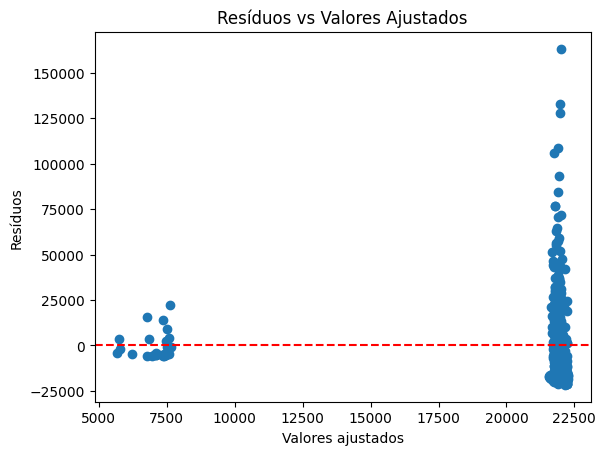

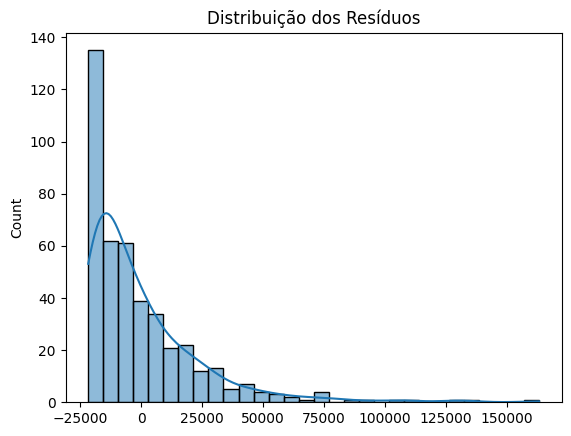

NameError: name 'stats' is not defined

In [38]:
# Resíduos
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

# Plot resíduos vs valores ajustados
plt.scatter(valores_ajustados, residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Ajustados')
plt.show()

# Histograma dos resíduos
sns.histplot(residuos, kde=True)
plt.title('Distribuição dos Resíduos')
plt.show()

# Teste de normalidade dos resíduos
stat, p = stats.shapiro(residuos)
print(f'Teste de Shapiro-Wilk: stat={stat:.4f}, p-valor={p:.4f}')


## testando com o valor do abandono Encino Medio 

In [40]:
# Supondo que o DataFrame original se chame 'df'
# Criar DataFrame para Abandono no Ensino Fundamental
abandono_ef = df.melt(
    id_vars=["Estado"],  # Coluna fixa
    value_vars=[col for col in df.columns if "Abandono_EM" in col],  # Selecionar colunas de abandono
    var_name="Ano",  # Nome da nova coluna que armazenará os anos
    value_name="Abandono_EM"  # Nome da coluna com os valores de abandono
)
# Extrair o ano do nome da coluna (ex.: "Abandono_EF2007" → 2007)
abandono_ef["Ano"] = abandono_ef["Ano"].str.extract(r'(\d{4})').astype(int)

# Criar DataFrame para Valor Médio do Bolsa Família
valor_bf = df.melt(
    id_vars=["Estado"],
    value_vars=[col for col in df.columns if "valor_medio_bf_ajustado_" in col],
    var_name="Ano",
    value_name="Valor_medio_BF"
)
valor_bf["Ano"] = valor_bf["Ano"].str.extract(r'(\d{4})').astype(int)

# Juntar os DataFrames por Estado e Ano
df_final = pd.merge(abandono_ef, valor_bf, on=["Estado", "Ano"])

# Verificar os primeiros registros
print(df_final.head())

     Estado   Ano  Abandono_EM  Valor_medio_BF
0      Acre  2007         5512          184.37
1   Alagoas  2007        32874          175.03
2     Amapá  2007         8513          189.19
3  Amazonas  2007        21077          189.42
4     Bahia  2007       161873          178.15


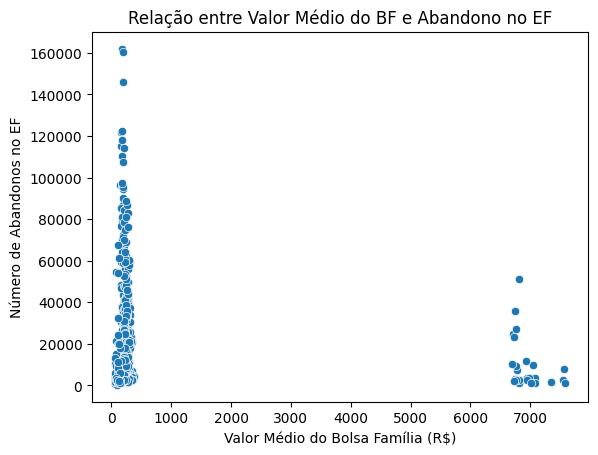

In [42]:
sns.scatterplot(data=df_final, x="Valor_medio_BF", y="Abandono_EM")
plt.title("Relação entre Valor Médio do BF e Abandono no EF")
plt.xlabel("Valor Médio do Bolsa Família (R$)")
plt.ylabel("Número de Abandonos no EF")
plt.show()

In [44]:
correlacao = df_final[["Abandono_EM", "Valor_medio_BF"]].corr()
print(correlacao)

                Abandono_EM  Valor_medio_BF
Abandono_EM        1.000000       -0.151239
Valor_medio_BF    -0.151239        1.000000


In [46]:
import statsmodels.api as sm

# Definir variáveis
X = df_final["Valor_medio_BF"]  # Variável independente
X = sm.add_constant(X)  # Adiciona o termo de intercepto (beta_0)
y = df_final["Abandono_EM"]  # Variável dependente

# Ajustar o modelo
modelo = sm.OLS(y, X).fit()

# Resumo do modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Abandono_EM   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     10.07
Date:                Fri, 18 Apr 2025   Prob (F-statistic):            0.00162
Time:                        23:25:58   Log-Likelihood:                -5026.8
No. Observations:                 432   AIC:                         1.006e+04
Df Residuals:                     430   BIC:                         1.007e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           2.706e+04   1417.282     19.

### o valore de R-squared ainda é muito baixo

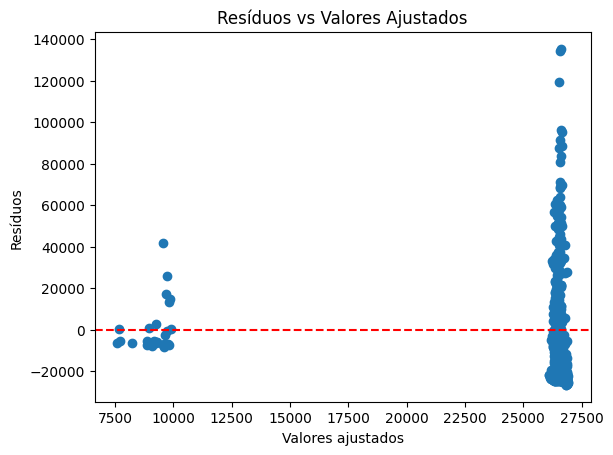

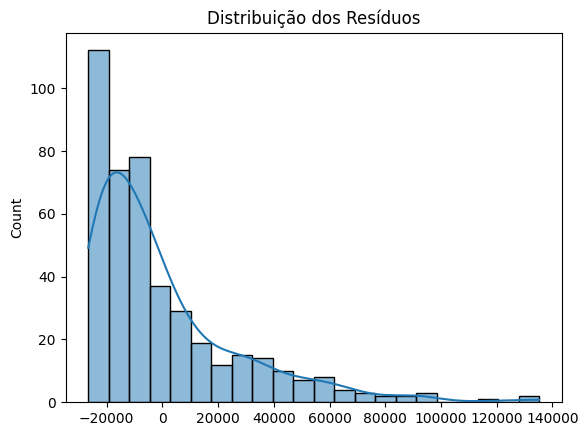

NameError: name 'stats' is not defined

In [47]:
# Resíduos
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

# Plot resíduos vs valores ajustados
plt.scatter(valores_ajustados, residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Ajustados')
plt.show()

# Histograma dos resíduos
sns.histplot(residuos, kde=True)
plt.title('Distribuição dos Resíduos')
plt.show()

# Teste de normalidade dos resíduos
stat, p = stats.shapiro(residuos)
print(f'Teste de Shapiro-Wilk: stat={stat:.4f}, p-valor={p:.4f}')

## 2 -analise de regreção usando o valor da quantidade de familia pelo abandono 

In [62]:
# Criar DataFrame no formato long para Abandono EF
# Certifique-se de que as colunas que contêm "Abandono_EF" estejam no DataFrame
abandono_ef = df.melt(
    id_vars=["Estado"],  # Variável fixa
    value_vars=[col for col in df.columns if "Abandono_EF" in col],  # Seleciona as colunas de Abandono_EF
    var_name="Ano",  # Nome da nova coluna de Ano
    value_name="Abandono_EF"  # Nome da nova coluna de valores de Abandono_EF
)

# Extrair o ano das colunas de "Ano" e garantir que é um inteiro
abandono_ef["Ano"] = abandono_ef["Ano"].str.extract(r'(\d{4})').astype(int)

# Criar DataFrame no formato long para Qtd_familias_BF
# Certifique-se de que as colunas que contêm "qtd_familias_beneficiarias" estejam no DataFrame
qtd_familias = df.melt(
    id_vars=["Estado"],  # Variável fixa
    value_vars=[col for col in df.columns if "qtd_familias_beneficiarias" in col],  # Seleciona as colunas de qtd_familias
    var_name="Ano",  # Nome da nova coluna de Ano
    value_name="Qtd_familias_BF"  # Nome da nova coluna de valores de qtd_familias
)

# Extrair o ano das colunas de "Ano" e garantir que é um inteiro
qtd_familias["Ano"] = qtd_familias["Ano"].str.extract(r'(\d{4})').astype(int)

# Juntar os dois DataFrames com base nas colunas "Estado" e "Ano"
df_modelo = pd.merge(abandono_ef, qtd_familias, on=["Estado", "Ano"])

# Verificar dados nulos
print(df_modelo.isnull().sum())

# Mostrar as primeiras linhas do DataFrame resultante para verificar a junção
print(df_modelo.head())

# Opcional: Normalizar o abandono escolar por população (se disponível)
# df_modelo["Abandono_EF_por1000"] = df_modelo["Abandono_EF"] / df_modelo["Populacao"] * 1000

Estado             0
Ano                0
Abandono_EF        0
Qtd_familias_BF    0
dtype: int64
     Estado   Ano  Abandono_EF  Qtd_familias_BF
0      Acre  2007         4470          53543.0
1   Alagoas  2007        48121         343985.0
2     Amapá  2007         6930          32564.0
3  Amazonas  2007        51244         212017.0
4     Bahia  2007       185146        1407187.0


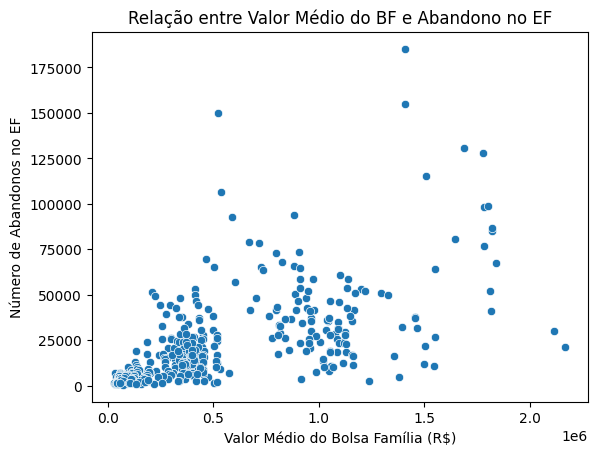

In [64]:
sns.scatterplot(data=df_modelo, x="Qtd_familias_BF", y="Abandono_EF")
plt.title("Relação entre Valor Médio do BF e Abandono no EF")
plt.xlabel("Valor Médio do Bolsa Família (R$)")
plt.ylabel("Número de Abandonos no EF")
plt.show()

In [68]:
correlacao = df_modelo[["Abandono_EF", "Qtd_familias_BF"]].corr()
print(correlacao)

                 Abandono_EF  Qtd_familias_BF
Abandono_EF         1.000000         0.629987
Qtd_familias_BF     0.629987         1.000000


In [69]:
import statsmodels.api as sm

# Definir variáveis
X = df_modelo["Qtd_familias_BF"]  # Variável independente
X = sm.add_constant(X)  # Adiciona o termo de intercepto (beta_0)
y = df_modelo["Abandono_EF"]  # Variável dependente

# Ajustar o modelo
modelo = sm.OLS(y, X).fit()

# Resumo do modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Abandono_EF   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     283.0
Date:                Fri, 18 Apr 2025   Prob (F-statistic):           3.72e-49
Time:                        23:52:22   Log-Likelihood:                -4876.7
No. Observations:                 432   AIC:                             9757.
Df Residuals:                     430   BIC:                             9766.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3890.7487   1379.056     

### Coeficiente de Valor_medio_BF (0.0346 ): Para cada  1 familia incruida, há um aumento de 0.0346  no número de abandonos no EF.não sei se isso esta correto. pode ser uma ma interpretação minha ou um erro na regreção, qualquer que seja o motivo isso não faz sentido.
### P-valor (0.005):A relação é estatisticamente significativa (p < 0.05).

### R² (0.397):o valor é mediana. 

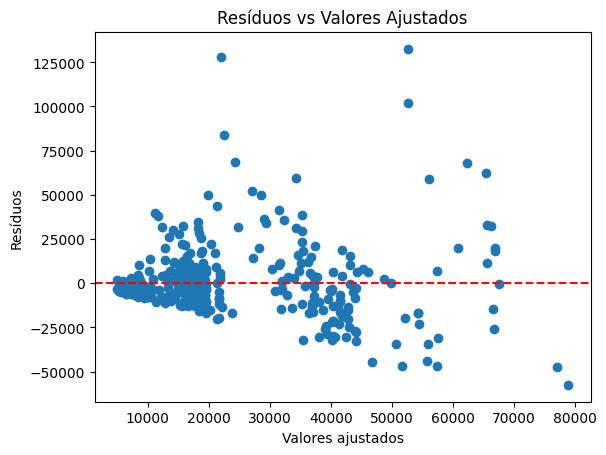

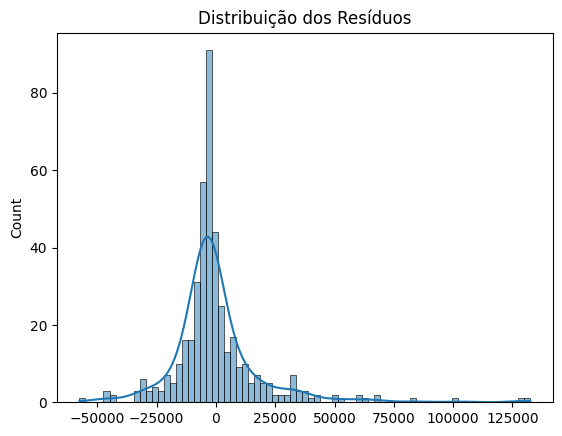

NameError: name 'stats' is not defined

In [70]:
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

# Plot resíduos vs valores ajustados
plt.scatter(valores_ajustados, residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Ajustados')
plt.show()

# Histograma dos resíduos
sns.histplot(residuos, kde=True)
plt.title('Distribuição dos Resíduos')
plt.show()

# Teste de normalidade dos resíduos
stat, p = stats.shapiro(residuos)
print(f'Teste de Shapiro-Wilk: stat={stat:.4f}, p-valor={p:.4f}')

# 3 -ANALISE usando quantidade de famílias beneficiárias do Bolsa Família e taxa de abandono escolar por ano pela taxa de abandono 

In [49]:
# Dados de Abandono EF
abandono_ef = df.melt(
    id_vars=["Estado"],
    value_vars=[col for col in df.columns if "Abandono_EF" in col],
    var_name="Ano",
    value_name="Abandono_EF"
)
abandono_ef["Ano"] = abandono_ef["Ano"].str.extract(r'(\d{4})').astype(int)

# Dados de Abandono EM
abandono_em = df.melt(
    id_vars=["Estado"],
    value_vars=[col for col in df.columns if "Abandono_EM" in col],
    var_name="Ano",
    value_name="Abandono_EM"
)
abandono_em["Ano"] = abandono_em["Ano"].str.extract(r'(\d{4})').astype(int)

# Dados de Quantidade de Famílias
qtd_familias = df.melt(
    id_vars=["Estado"],
    value_vars=[col for col in df.columns if "qtd_familias_beneficiarias" in col],
    var_name="Ano",
    value_name="Qtd_familias_BF"
)
qtd_familias["Ano"] = qtd_familias["Ano"].str.extract(r'(\d{4})').astype(int)

# Dados de Valor Médio
valor_medio = df.melt(
    id_vars=["Estado"],
    value_vars=[col for col in df.columns if "valor_medio_bf_ajustado" in col],
    var_name="Ano",
    value_name="Valor_medio_BF"
)
valor_medio["Ano"] = valor_medio["Ano"].str.extract(r'(\d{4})').astype(int)

# Unir tudo em um único DataFrame
df_painel = pd.merge(abandono_ef, abandono_em, on=["Estado", "Ano"])
df_painel = pd.merge(df_painel, qtd_familias, on=["Estado", "Ano"])
df_painel = pd.merge(df_painel, valor_medio, on=["Estado", "Ano"])

# Ordenar por Estado e Ano
df_painel = df_painel.sort_values(["Estado", "Ano"])
print(df_painel.head())

    Estado   Ano  Abandono_EF  Abandono_EM  Qtd_familias_BF  Valor_medio_BF
0     Acre  2007         4470         5512          53543.0          184.37
27    Acre  2008         6739         5563          56773.0          208.73
54    Acre  2009         7147         5110          58881.0          220.64
81    Acre  2010         6316         5553          59688.0          231.49
108   Acre  2011         5655         4543          57789.0          257.21


In [50]:
print(df_painel.describe())

               Ano    Abandono_EF    Abandono_EM  Qtd_familias_BF  \
count   432.000000     432.000000     432.000000     4.320000e+02   
mean   2014.562500   20982.439815   25425.229167     4.939593e+05   
std       4.722045   24925.880465   27718.925272     4.538248e+05   
min    2007.000000     369.000000     194.000000     3.174700e+04   
25%    2010.750000    4422.500000    5571.250000     1.328580e+05   
50%    2014.500000   11680.000000   15793.500000     3.551160e+05   
75%    2018.250000   28008.250000   34105.250000     8.126090e+05   
max    2023.000000  185146.000000  161873.000000     2.167967e+06   

       Valor_medio_BF  
count      432.000000  
mean       638.803310  
std       1634.252702  
min         54.380000  
25%        189.115000  
50%        227.245000  
75%        270.945000  
max       7588.300000  


In [51]:
correlacoes = df_painel[["Abandono_EF", "Abandono_EM", "Qtd_familias_BF", "Valor_medio_BF"]].corr()
print(correlacoes)

                 Abandono_EF  Abandono_EM  Qtd_familias_BF  Valor_medio_BF
Abandono_EF         1.000000     0.767106         0.629987       -0.144410
Abandono_EM         0.767106     1.000000         0.578455       -0.151239
Qtd_familias_BF     0.629987     0.578455         1.000000        0.085626
Valor_medio_BF     -0.144410    -0.151239         0.085626        1.000000


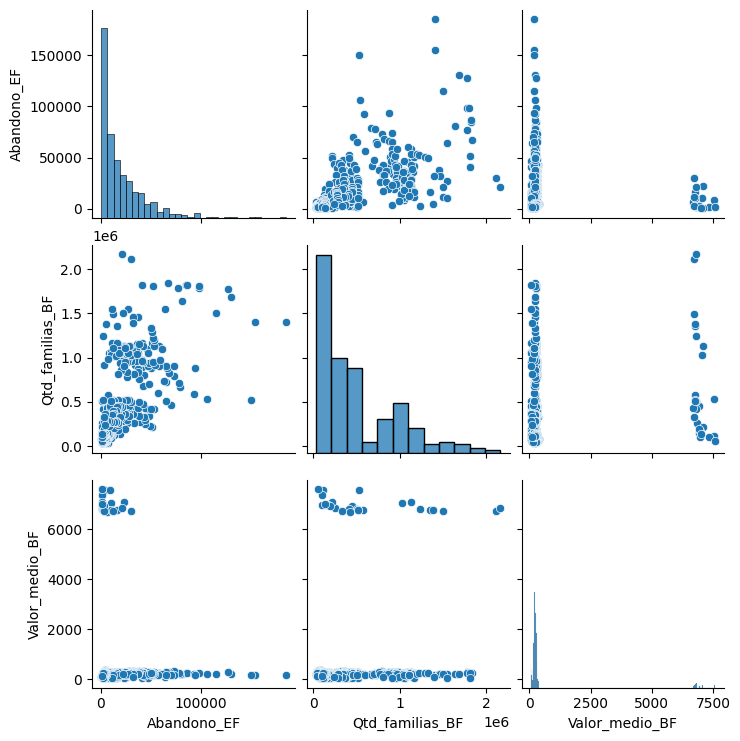

In [52]:
# Pairplot para relações multivariadas
sns.pairplot(df_painel[["Abandono_EF", "Qtd_familias_BF", "Valor_medio_BF"]])
plt.show()

In [53]:
# Variáveis independentes
X = df_painel[["Qtd_familias_BF", "Valor_medio_BF"]]
X = sm.add_constant(X)  # Adiciona intercepto
y = df_painel["Abandono_EF"]

# Modelo OLS
modelo_ef = sm.OLS(y, X).fit()
print(modelo_ef.summary())

                            OLS Regression Results                            
Dep. Variable:            Abandono_EF   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     166.2
Date:                Fri, 18 Apr 2025   Prob (F-statistic):           3.66e-54
Time:                        23:35:48   Log-Likelihood:                -4862.0
No. Observations:                 432   AIC:                             9730.
Df Residuals:                     429   BIC:                             9742.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5373.4177   1361.546     

In [54]:
y = df_painel["Abandono_EM"]
modelo_em = sm.OLS(y, X).fit()
print(modelo_em.summary())

                            OLS Regression Results                            
Dep. Variable:            Abandono_EM   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     128.8
Date:                Fri, 18 Apr 2025   Prob (F-statistic):           1.53e-44
Time:                        23:36:17   Log-Likelihood:                -4930.2
No. Observations:                 432   AIC:                             9866.
Df Residuals:                     429   BIC:                             9879.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            9641.9747   1594.348     

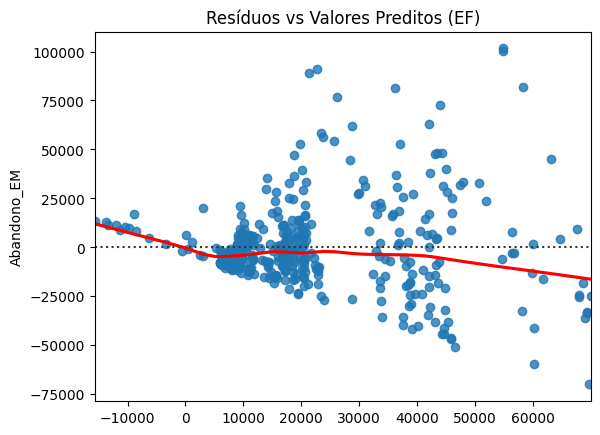

In [56]:
sns.residplot(x=y_pred_ef, y=y, lowess=True, line_kws={"color": "red"})
plt.title("Resíduos vs Valores Preditos (EF)")
plt.show()